Initial A* path found.
Initial path length: 58
Dynamic obstacle detected at (0, 11) -> A* replanning performed
Dynamic obstacle detected at (1, 17) -> A* replanning performed
Dynamic obstacle detected at (2, 23) -> A* replanning performed
Dynamic obstacle detected at (3, 29) -> A* replanning performed
Dynamic obstacle detected at (10, 29) -> A* replanning performed
Dynamic obstacle detected at (15, 29) -> A* replanning performed

UGV DYNAMIC OBSTACLE NAVIGATION USING A* SEARCH

Start Position       : (0, 0)
Goal Position        : (29, 29)
Final UGV Position   : (29, 29)
Path Distance        : 62 grid cells
Nodes Expanded       : 32533
Dynamic Obstacles    : 6
Number of Re-plans   : 6
Execution Time       : 0.0971 seconds
Success Rate         : 100 %

Navigation Status     : SUCCESS

Dynamic Obstacles Generated:
[(0, 11), (1, 17), (2, 23), (3, 29), (10, 29), (15, 29)]


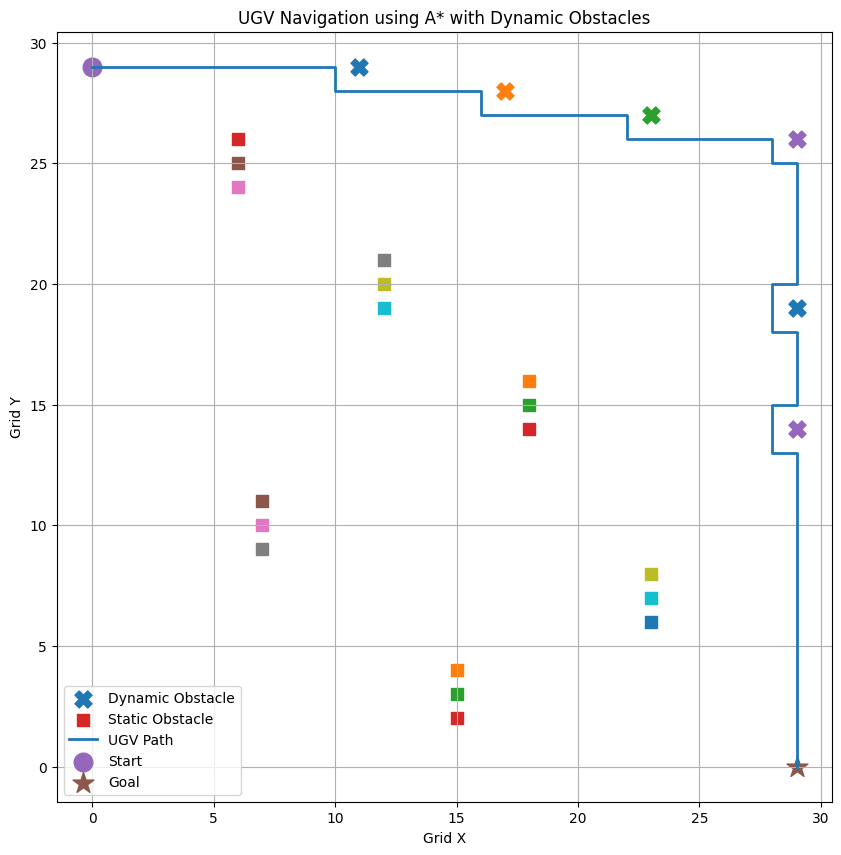

In [5]:
# ================================================================
# Q3: UGV NAVIGATION IN DYNAMIC OBSTACLE ENVIRONMENT USING A*
# ================================================================

import heapq
import time
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. GRID SETTINGS
# ------------------------------------------------
ROWS = 30
COLS = 30

START = (0, 0)
GOAL = (29, 29)

# ------------------------------------------------
# 2. CREATE STATIC OBSTACLES
# ------------------------------------------------
grid = [[0 for _ in range(COLS)] for _ in range(ROWS)]

# Static obstacles
static_obstacles = [
    (3, 6), (4, 6), (5, 6),
    (8, 12), (9, 12), (10, 12),
    (13, 18), (14, 18), (15, 18),
    (18, 7), (19, 7), (20, 7),
    (21, 23), (22, 23), (23, 23),
    (25, 15), (26, 15), (27, 15)
]

for r, c in static_obstacles:
    grid[r][c] = 1

grid[START[0]][START[1]] = 0
grid[GOAL[0]][GOAL[1]] = 0


# ------------------------------------------------
# 3. A* SEARCH
# ------------------------------------------------
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def get_neighbors(node):
    r, c = node

    directions = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1)
    ]

    result = []

    for dr, dc in directions:
        nr = r + dr
        nc = c + dc

        if 0 <= nr < ROWS and 0 <= nc < COLS:
            result.append((nr, nc))

    return result


def a_star(grid, start, goal):

    open_list = []

    heapq.heappush(
        open_list,
        (heuristic(start, goal), 0, start)
    )

    came_from = {}
    g_cost = {start: 0}

    closed = set()
    nodes_expanded = 0

    while open_list:

        f, g, current = heapq.heappop(open_list)

        if current in closed:
            continue

        closed.add(current)
        nodes_expanded += 1

        # Goal reached
        if current == goal:

            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)
            path.reverse()

            return path, nodes_expanded

        for neighbor in get_neighbors(current):

            r, c = neighbor

            if grid[r][c] == 1:
                continue

            if neighbor in closed:
                continue

            new_g = g_cost[current] + 1

            if neighbor not in g_cost or new_g < g_cost[neighbor]:

                g_cost[neighbor] = new_g
                came_from[neighbor] = current

                f_cost = new_g + heuristic(neighbor, goal)

                heapq.heappush(
                    open_list,
                    (f_cost, new_g, neighbor)
                )

    return None, nodes_expanded


# ------------------------------------------------
# 4. INITIAL PATH
# ------------------------------------------------
path, nodes = a_star(grid, START, GOAL)

if path is None:

    print("No initial path found.")

else:

    print("Initial A* path found.")
    print("Initial path length:", len(path) - 1)

    current = START

    travelled_path = [current]

    total_nodes = nodes

    dynamic_obstacles = []

    replans = 0

    start_time = time.time()

    # ------------------------------------------------
    # 5. DYNAMIC NAVIGATION
    # ------------------------------------------------
    steps_since_event = 0

    MAX_DYNAMIC_OBSTACLES = 6

    while current != GOAL:

        # ------------------------------------------------
        # Recalculate current optimal path
        # ------------------------------------------------
        path, nodes = a_star(grid, current, GOAL)

        total_nodes += nodes

        if path is None:
            break

        # ------------------------------------------------
        # Introduce dynamic obstacle every 7 steps
        # ------------------------------------------------
        if (
            steps_since_event >= 7
            and len(dynamic_obstacles) < MAX_DYNAMIC_OBSTACLES
            and len(path) > 6
        ):

            # Choose a cell directly ahead on the ACTUAL path
            candidate = path[4]

            # Make sure candidate is not goal
            if candidate != GOAL:

                # Add temporary dynamic obstacle
                grid[candidate[0]][candidate[1]] = 1

                # Check whether alternate route exists
                new_path, new_nodes = a_star(
                    grid,
                    current,
                    GOAL
                )

                if new_path is not None:

                    # Dynamic obstacle accepted
                    dynamic_obstacles.append(candidate)

                    replans += 1

                    total_nodes += new_nodes

                    print(
                        f"Dynamic obstacle detected at {candidate} "
                        f"-> A* replanning performed"
                    )

                    # Reset event counter
                    steps_since_event = 0

                else:

                    # Remove obstacle if it blocks all routes
                    grid[candidate[0]][candidate[1]] = 0


        # ------------------------------------------------
        # Get latest path after obstacle detection
        # ------------------------------------------------
        path, nodes = a_star(grid, current, GOAL)

        total_nodes += nodes

        if path is None:
            break

        # ------------------------------------------------
        # Move one step
        # ------------------------------------------------
        if len(path) < 2:
            break

        next_position = path[1]

        # Safety check
        if grid[next_position[0]][next_position[1]] == 1:
            continue

        current = next_position

        travelled_path.append(current)

        steps_since_event += 1


    # ------------------------------------------------
    # 6. PERFORMANCE MEASURES
    # ------------------------------------------------
    execution_time = time.time() - start_time

    path_distance = len(travelled_path) - 1

    success = current == GOAL

    success_rate = 100 if success else 0


    # ------------------------------------------------
    # 7. DISPLAY RESULTS
    # ------------------------------------------------
    print("\n" + "=" * 65)
    print("UGV DYNAMIC OBSTACLE NAVIGATION USING A* SEARCH")
    print("=" * 65)

    print("\nStart Position       :", START)
    print("Goal Position        :", GOAL)

    print("Final UGV Position   :", current)

    print("Path Distance        :", path_distance, "grid cells")

    print("Nodes Expanded       :", total_nodes)

    print("Dynamic Obstacles    :", len(dynamic_obstacles))

    print("Number of Re-plans   :", replans)

    print("Execution Time       :", round(execution_time, 4), "seconds")

    print("Success Rate         :", success_rate, "%")

    if success:
        print("\nNavigation Status     : SUCCESS")
    else:
        print("\nNavigation Status     : FAILED")

    print("\nDynamic Obstacles Generated:")
    print(dynamic_obstacles)


    # ------------------------------------------------
    # 8. VISUALIZATION
    # ------------------------------------------------
    plt.figure(figsize=(10, 10))

    # Static and dynamic obstacles
    for r in range(ROWS):
        for c in range(COLS):

            if grid[r][c] == 1:

                if (r, c) in dynamic_obstacles:

                    plt.scatter(
                        c,
                        ROWS - 1 - r,
                        marker='X',
                        s=150,
                        label="Dynamic Obstacle"
                        if dynamic_obstacles.index((r, c)) == 0
                        else ""
                    )

                else:

                    plt.scatter(
                        c,
                        ROWS - 1 - r,
                        marker='s',
                        s=70,
                        label="Static Obstacle"
                        if (r, c) == static_obstacles[0]
                        else ""
                    )


    # UGV travelled path
    x = [p[1] for p in travelled_path]
    y = [ROWS - 1 - p[0] for p in travelled_path]

    plt.plot(
        x,
        y,
        linewidth=2,
        label="UGV Path"
    )


    # Start
    plt.scatter(
        START[1],
        ROWS - 1 - START[0],
        marker='o',
        s=180,
        label="Start"
    )


    # Goal
    plt.scatter(
        GOAL[1],
        ROWS - 1 - GOAL[0],
        marker='*',
        s=250,
        label="Goal"
    )


    plt.title(
        "UGV Navigation using A* with Dynamic Obstacles"
    )

    plt.xlabel("Grid X")
    plt.ylabel("Grid Y")

    plt.grid(True)
    plt.legend()

    plt.show()